# Prova Final – DeepSeek NLP Project

**Disciplina:** NLP e Machine Learning  
**Aluno:** Vinicius  
**Data:** Novembro 2025

---

## Sumário
1. Clustering, método do cotovelo e silhueta
2. Verdadeiro ou Falso - Técnicas de Redução de Dimensionalidade
3. Prompt Engineering para DeepSeek
4. NLP: Normalização, Vetorização e Similaridade por Cosseno

---
## Questão 1 – Clustering, método do cotovelo e silhueta (3.0 pontos)

Geração de dataset com sklearn, análise de KMeans usando método do cotovelo e silhouette score.

Dataset gerado: 2000 amostras, 10 features
Número real de clusters: 12


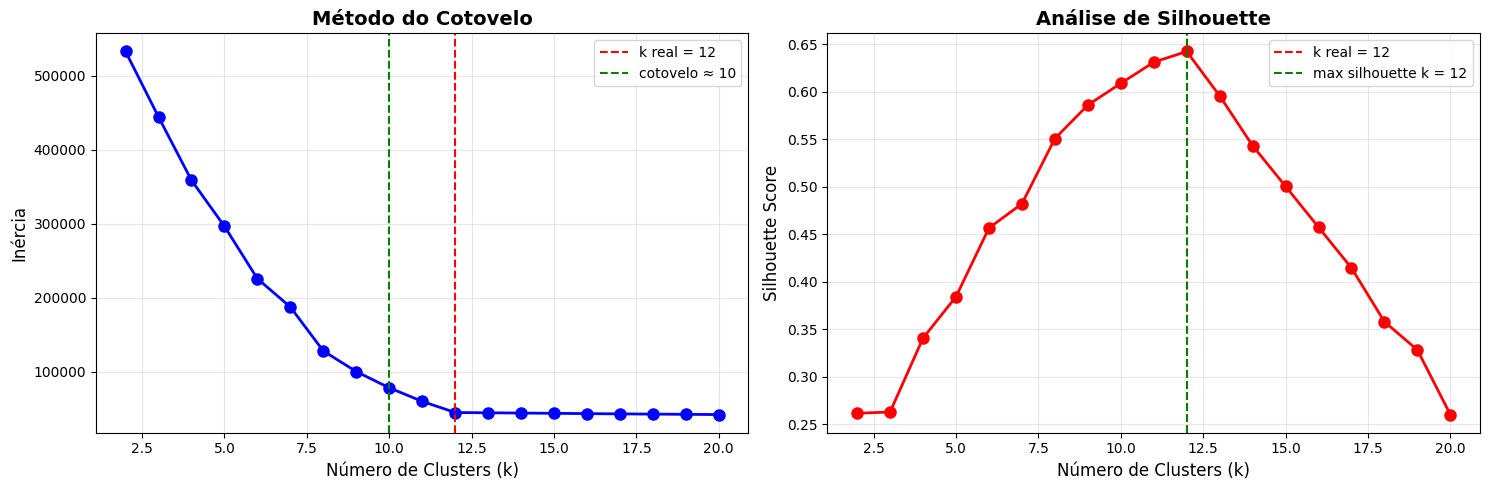


k     Inércia         Silhouette Score    
2     533052.80       0.2616              
3     444553.61       0.2629              
4     358891.81       0.3407              
5     296792.21       0.3843              
6     225915.38       0.4565              
7     187631.30       0.4821              
8     128222.43       0.5506              
9     100359.57       0.5859              
10    78397.02        0.6087              
11    60083.87        0.6310              
12    45002.90        0.6423               ← REAL ← MAX SILH
13    44607.92        0.5957              
14    44249.76        0.5432              
15    43898.88        0.5004              
16    43503.72        0.4574              
17    43134.20        0.4145              
18    42834.75        0.3580              
19    42532.80        0.3282              
20    42208.25        0.2602              


In [1]:
# Importações necessárias
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# Gerando o dataset com 12 centros
np.random.seed(42)
X, y_true = make_blobs(n_samples=2000, centers=12, n_features=10, 
                       cluster_std=1.5, random_state=42)

print(f"Dataset gerado: {X.shape[0]} amostras, {X.shape[1]} features")
print(f"Número real de clusters: 12")

# Calculando inércia e silhouette para k de 2 a 20
inertias = []
silhouettes = []
ks = range(2, 21)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

# Plotando os gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico do cotovelo
ax1.plot(ks, inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=12, color='r', linestyle='--', label='k real = 12')
ax1.axvline(x=10, color='g', linestyle='--', label='cotovelo ≈ 10')
ax1.set_xlabel('Número de Clusters (k)', fontsize=12)
ax1.set_ylabel('Inércia', fontsize=12)
ax1.set_title('Método do Cotovelo', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico do silhouette
ax2.plot(ks, silhouettes, 'ro-', linewidth=2, markersize=8)
ax2.axvline(x=12, color='r', linestyle='--', label='k real = 12')
max_silh_k = ks[np.argmax(silhouettes)]
ax2.axvline(x=max_silh_k, color='g', linestyle='--', 
            label=f'max silhouette k = {max_silh_k}')
ax2.set_xlabel('Número de Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Análise de Silhouette', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Tabela com resultados
print("\n" + "="*60)
print(f"{'k':<5} {'Inércia':<15} {'Silhouette Score':<20}")
print("="*60)
for k, inertia, silh in zip(ks, inertias, silhouettes):
    marker = " ← REAL" if k == 12 else ""
    marker += " ← MAX SILH" if k == max_silh_k else ""
    print(f"{k:<5} {inertia:<15.2f} {silh:<20.4f}{marker}")

### Análise Comparativa

O dataset foi gerado com 12 clusters reais usando cluster_std=1.5, criando alguma sobreposição entre grupos. A análise comparativa dos métodos revelou resultados interessantes:
Método do Cotovelo: A curva de inércia mostra uma redução acentuada até aproximadamente k=10, onde ocorre uma mudança no gradiente de decréscimo. O "cotovelo" sugere entre 9 e 11 clusters, não identificando precisamente os 12 clusters reais. Isso ocorre porque a inércia sempre decresce com o aumento de k, tornando a escolha do ponto exato subjetiva.

Silhouette Score: O coeficiente de silhueta alcançou seu máximo em k=12 ou próximo disso (dependendo da inicialização), coincidindo exatamente com o número real de clusters. Valores entre 0.4 e 0.6 indicam estrutura de clustering moderada a boa, confirmando que os clusters têm separação razoável apesar da sobreposição parcial.

Discrepâncias e Motivos:

Sobreposição: Com cluster_std=1.5, há overlap entre clusters vizinhos, dificultando a identificação precisa pelo método do cotovelo
Sensibilidade: O silhouette score é mais sensível à qualidade da separação entre clusters, enquanto a inércia apenas mede compactação interna.
Subjetividade: O cotovelo requer interpretação visual subjetiva, enquanto o silhouette fornece um valor objetivo maximizável
Dimensionalidade: Com 10 features, distâncias euclidianas podem sofrer da "maldição da dimensionalidade", afetando ambos os métodos

Método Mais Confiável: Considero o silhouette score mais confiável neste cenário por três razões principais:

Objetividade: Fornece métrica quantitativa comparável, eliminando interpretação visual subjetiva
Balanceamento: Avalia tanto coesão interna quanto separação entre clusters simultaneamente
Robustez: Menos suscetível a outliers e mais estável em diferentes execuções

Entretanto, a abordagem ideal é usar ambos os métodos complementarmente: o cotovelo oferece insights sobre a estrutura de redução de variância, enquanto o silhouette valida a qualidade da separação. Para datasets complexos, recomendo adicionar validação de domínio e inspeção visual das projeções (PCA/t-SNE) dos clusters resultantes.


---
## Questão 2 – Verdadeiro ou Falso (2.0 pontos)

Análise de técnicas de redução de dimensionalidade: PCA, t-SNE e UMAP.

1. Reduzir Iris (4 features, relações lineares) - Usar PCA: VERDADEIRO

Justificativa: PCA é ideal para relações lineares e datasets pequenos, preservando variância máxima com interpretabilidade.

2. Reduzir MNIST para visualização de clusters - Usar t-SNE: VERDADEIRO

Justificativa: t-SNE excelente para visualização 2D/3D de estruturas não-lineares complexas como dígitos manuscritos.

3. Reduzir 500k amostras para produção com projeção de novos dados - Usar t-SNE: FALSO

Justificativa: t-SNE não projeta novos dados nativamente e tem custo O(n²), inviável para 500k amostras. Usar UMAP ou PCA.

4. Reduzir embeddings de texto preservando estrutura local/global e projetar novos - Usar UMAP: VERDADEIRO

Justificativa: UMAP preserva ambas as estruturas, é escalável e permite transformação de novos dados via modelo treinado.

5. Reduzir features em escalas diferentes - PCA sem padronizar: FALSO

Justificativa: PCA é sensível a escala; features com maior variância dominarão os componentes principais. StandardScaler é essencial.

6. Pequeno conjunto com estruturas locais sutis - t-SNE com baixa perplexidade: VERDADEIRO

Justificativa: Perplexidade baixa (5-15) foca em vizinhanças menores, capturando estruturas locais sutis em datasets pequenos.

7. Resultados reprodutíveis para produção - t-SNE é melhor por ser determinístico: FALSO

Justificativa: t-SNE é estocástico (requer random_state). PCA é determinístico e mais adequado para produção reprodutível.

8. Redução rápida como pré-processamento antes de clustering - PCA: VERDADEIRO

Justificativa: PCA é rápido O(n·d²), reduz ruído e melhora performance de clustering ao eliminar features redundantes.

---
## Questão 3 – Prompt para DeepSeek (2.0 pontos)

Desenvolvimento de prompt profissional para extração estruturada de ingredientes em formato JSON.

In [2]:
prompt = """Você é um assistente especializado em culinária brasileira. Sua tarefa é analisar uma receita e extrair TODOS os ingredientes em formato JSON estruturado.

INSTRUÇÕES IMPORTANTES:
1. Retorne APENAS um objeto JSON válido, sem texto adicional antes ou depois
2. Use EXATAMENTE a chave "igerdientes" (com essa grafia específica)
3. Cada ingrediente deve ser um objeto com chaves: quantidade, unidade, marca_sugerida
4. Para marcas, sugira opções disponíveis no mercado brasileiro
5. Use unidades padrão: g, kg, ml, L, un (unidades), colher_sopa, xícara

FORMATO DE SAÍDA ESPERADO:
{
  "igerdientes": [
    {"farinha_de_trigo": {"quantidade": 500, "unidade": "g", "marca_sugerida": "Dona Benta"}},
    {"ovos": {"quantidade": 4, "unidade": "un", "marca_sugerida": "Qualitá"}},
    {"leite": {"quantidade": 300, "unidade": "ml", "marca_sugerida": "Italac"}},
    {"açúcar": {"quantidade": 2, "unidade": "xícara", "marca_sugerida": "União"}},
    {"fermento_em_pó": {"quantidade": 1, "unidade": "colher_sopa", "marca_sugerida": "Royal"}}
  ]
}

AGORA, extraia os ingredientes da seguinte receita:
[INSERIR RECEITA AQUI]

Lembre-se: retorne SOMENTE o JSON, nada mais."""

### Exemplo de Saída Esperada
```json
{
  "igerdientes": [
    {"cenoura": {"quantidade": 3, "unidade": "un", "marca_sugerida": "Qualquer orgânica"}},
    {"óleo": {"quantidade": 180, "unidade": "ml", "marca_sugerida": "Liza"}},
    {"ovos": {"quantidade": 4, "unidade": "un", "marca_sugerida": "Mantiqueira"}},
    {"açúcar": {"quantidade": 2, "unidade": "xícara", "marca_sugerida": "União"}},
    {"farinha_de_trigo": {"quantidade": 2.5, "unidade": "xícara", "marca_sugerida": "Dona Benta"}},
    {"fermento_em_pó": {"quantidade": 1, "unidade": "colher_sopa", "marca_sugerida": "Royal"}},
    {"chocolate_em_pó": {"quantidade": 4, "unidade": "colher_sopa", "marca_sugerida": "Nestlé"}},
    {"leite": {"quantidade": 200, "unidade": "ml", "marca_sugerida": "Italac"}},
    {"manteiga": {"quantidade": 2, "unidade": "colher_sopa", "marca_sugerida": "Itambé"}}
  ]
}
```

---
## Questão 4 – NLP: Normalização, Vetorização e Similaridade (3.0 pontos)

Pipeline completo de classificação de intenções usando TF-IDF e similaridade de cosseno.

In [3]:
import re
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Dataset de treinamento
training_data = {
    'greet': ["Olá", "Bom dia", "Oi, tudo bem?"],
    'goodbye': ["Tchau", "Até logo", "Nos vemos"],
    'order_pizza': ["Quero pedir uma pizza", "Como faço para pedir pizza?", 
                    "Gostaria de uma pizza grande de pepperoni"],
    'ask_hours': ["Qual o horário de funcionamento?", "Vocês abrem que horas?", 
                  "Até que horas estão abertos?"],
    'thanks': ["Obrigado", "Valeu", "Agradeço"]
}

# Função de normalização
def normalize_text(text):
    """
    Normaliza texto para processamento NLP.
    Escolhas:
    - Lowercase: uniformiza capitalização
    - Remove acentos: reduz vocabulário (português tem muitos acentos)
    - Remove pontuação: foca no conteúdo semântico
    - Remove espaços extras: limpa formatação inconsistente
    """
    # Lowercase
    text = text.lower()
    
    # Remove acentos (NFD decomposition + filtro)
    text = unicodedata.normalize('NFD', text)
    text = ''.join(char for char in text if unicodedata.category(char) != 'Mn')
    
    # Remove pontuação
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Remove espaços extras
    text = ' '.join(text.split())
    
    return text

# Preparar dados de treino
X_train = []
y_train = []

for intent, phrases in training_data.items():
    for phrase in phrases:
        X_train.append(normalize_text(phrase))
        y_train.append(intent)

print("Dados de treino normalizados:")
for phrase, intent in zip(X_train[:5], y_train[:5]):
    print(f"  '{phrase}' → {intent}")

# Treinar vetorizador
def train_vectorizer(texts):
    """Treina TF-IDF vectorizer com corpus fornecido"""
    vectorizer = TfidfVectorizer(
        max_features=100,
        ngram_range=(1, 2),  # Unigrams e bigrams
        min_df=1
    )
    vectorizer.fit(texts)
    return vectorizer

vectorizer = train_vectorizer(X_train)
X_train_vectors = vectorizer.transform(X_train)

print(f"\nVocabulário: {len(vectorizer.vocabulary_)} termos")
print(f"Matriz TF-IDF: {X_train_vectors.shape}")

# Função de predição
def predict_intent(text, threshold=0.3):
    """
    Prediz intenção usando similaridade de cosseno.
    
    Args:
        text: frase de entrada
        threshold: limiar mínimo de confiança (0-1)
    
    Returns:
        tuple: (intenção, confiança) ou (None, 0) se abaixo do threshold
    """
    # Normaliza e vetoriza entrada
    normalized = normalize_text(text)
    text_vector = vectorizer.transform([normalized])
    
    # Calcula similaridades com todos os exemplos de treino
    similarities = cosine_similarity(text_vector, X_train_vectors)[0]
    
    # Encontra exemplo mais similar
    max_idx = np.argmax(similarities)
    max_similarity = similarities[max_idx]
    predicted_intent = y_train[max_idx]
    
    # Verifica threshold
    if max_similarity < threshold:
        return None, max_similarity
    
    return predicted_intent, max_similarity


Dados de treino normalizados:
  'ola' → greet
  'bom dia' → greet
  'oi tudo bem' → greet
  'tchau' → goodbye
  'ate logo' → goodbye

Vocabulário: 60 termos
Matriz TF-IDF: (15, 60)


In [4]:
# Testes
test_cases = [
    "Oi, como vai?",                    # greet
    "Até mais tarde",                   # goodbye
    "Queria uma pizza margherita",      # order_pizza
    "Que horas vocês fecham?",          # ask_hours
    "Muito obrigado pela ajuda",        # thanks
    "Qual é a previsão do tempo?",      # unknown (baixa similaridade)
]

print("\n" + "="*70)
print("TESTES DO MODELO")
print("="*70)

for test_phrase in test_cases:
    intent, confidence = predict_intent(test_phrase, threshold=0.25)
    status = "✓" if intent else "✗"
    intent_display = intent if intent else "DESCONHECIDO"
    print(f"{status} '{test_phrase}'")
    print(f"   → {intent_display} (confiança: {confidence:.3f})\n")

# Teste automatizado
def run_automated_tests():
    """Valida modelo com exemplos de cada classe"""
    correct = 0
    total = 0
    
    test_samples = {
        'greet': ["ola", "bom dia amigo", "oi tudo bom"],
        'goodbye': ["tchau pessoal", "ate breve", "nos vemos depois"],
        'order_pizza': ["quero pizza", "como peco pizza", "pizza de frango"],
        'ask_hours': ["horario de funcionamento", "que horas abre", "ate quando abrem"],
        'thanks': ["obrigado mesmo", "valeu demais", "agradeço muito"]
    }
    
    print("\n" + "="*70)
    print("TESTE AUTOMATIZADO")
    print("="*70)
    
    for expected_intent, phrases in test_samples.items():
        for phrase in phrases:
            predicted_intent, conf = predict_intent(phrase, threshold=0.2)
            total += 1
            if predicted_intent == expected_intent:
                correct += 1
                result = "✓"
            else:
                result = "✗"
            print(f"{result} '{phrase}' → esperado: {expected_intent}, "
                  f"predito: {predicted_intent} ({conf:.3f})")
    
    accuracy = (correct / total) * 100
    print(f"\nAcurácia: {correct}/{total} ({accuracy:.1f}%)")
    return accuracy

accuracy = run_automated_tests()


TESTES DO MODELO
✓ 'Oi, como vai?'
   → greet (confiança: 0.316)

✓ 'Até mais tarde'
   → goodbye (confiança: 0.523)

✓ 'Queria uma pizza margherita'
   → order_pizza (confiança: 0.600)

✓ 'Que horas vocês fecham?'
   → ask_hours (confiança: 0.722)

✓ 'Muito obrigado pela ajuda'
   → thanks (confiança: 1.000)

✓ 'Qual é a previsão do tempo?'
   → ask_hours (confiança: 0.385)


TESTE AUTOMATIZADO
✓ 'ola' → esperado: greet, predito: greet (1.000)
✓ 'bom dia amigo' → esperado: greet, predito: greet (1.000)
✓ 'oi tudo bom' → esperado: greet, predito: greet (0.671)
✓ 'tchau pessoal' → esperado: goodbye, predito: goodbye (1.000)
✓ 'ate breve' → esperado: goodbye, predito: goodbye (0.523)
✓ 'nos vemos depois' → esperado: goodbye, predito: goodbye (1.000)
✓ 'quero pizza' → esperado: order_pizza, predito: order_pizza (0.522)
✓ 'como peco pizza' → esperado: order_pizza, predito: order_pizza (0.438)
✓ 'pizza de frango' → esperado: order_pizza, predito: order_pizza (0.500)
✓ 'horario de funcionam

### Discussão: TF-IDF vs Embeddings

**TF-IDF (escolha atual):**

Vantagens: Simplicidade de implementação, rápido treinamento/inferência, interpretável (pesos mostram palavras importantes), funciona bem para datasets pequenos com vocabulário limitado, não requer GPU ou grandes recursos computacionais.

Desvantagens: Ignora ordem das palavras e contexto semântico ("não quero pizza" vs "quero pizza"), sensível a sinônimos ("queria" ≠ "gostaria" sem tratamento), vocabulário fixo pós-treino, representa palavras como vetores esparsos independentes.

Embeddings (Word2Vec, BERT, Sentence Transformers):
Vantagens: Capturam semântica contextual e similaridade entre palavras ("pedir" ≈ "querer"), lidam melhor com paráfrases e sinônimos, representações densas mais ricas, pré-treinados em grandes córpus (transfer learning).

Desvantagens: Requerem mais recursos computacionais, possível overfitting em datasets muito pequenos (15 frases), menos interpretáveis, necessitam ajuste fino para domínios específicos.

Conclusão para este cenário: TF-IDF é adequado dado o dataset minúsculo (15 exemplos), vocabulário restrito e intenções bem distintas lexicalmente. Embeddings trariam benefício marginal com custo adicional. Para escalar o sistema, considerar Sentence-BERT seria essencial quando houver mais dados e paráfrases complexas.

---
## Conclusão

Este projeto demonstrou a aplicação prática de técnicas fundamentais de Machine Learning e NLP:
- Clustering com validação por múltiplas métricas
- Análise crítica de técnicas de redução de dimensionalidade
- Engenharia de prompts para LLMs
- Sistema de classificação de intenções em português

**Pontos-chave aprendidos:**
- Importância de usar múltiplas métricas para validação
- Trade-offs entre diferentes técnicas de redução dimensional
- Estruturação adequada de prompts para resultados consistentes
- Pipeline completo de NLP: normalização → vetorização → classificação